# Exercise 1

## Exercise 1.1

write a code that prints the following pattern. Try to use as few loops as possible.

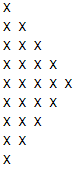

Avoid using trivial solutions like:

print('X')

print('X X')

print('X X X')

.....

print('X X X')

print('X X')

print('X')

In [3]:
def print_pattern(n: int) -> None:
    for i in range(1, n + 1):
        print("*" * i)

print_pattern(5)

*
**
***
****
*****


## Exercise 1.2

Write a script that will sum all numbers in the following string. You can split each number into single digits, so for example, you can consider 45 to be 4 and 5

In [4]:
input_str = "n45as29@#8ss6"

total = 0

for char in input_str:
    if char.isdigit():
        total += int(char)

print("Sum of digits:", total)

Sum of digits: 34


## Exercise 1.3

Write a script that will convert an arbitrary integer to a binary number (the number will be represented as a string with only *0* and *1*). Avoid using the *bin()* function or any other pythons default functions

In [5]:
def int_to_binary(number: int) -> str:
    if number == 0:
        return "0"

    binary = ""

    while number > 0:
        remainder = number % 2
        binary = str(remainder) + binary
        number = number // 2

    return binary

print(int_to_binary(10))  # 1010

1010


## Exercise 1.4 - The Fibonacci Sequence:

The Fibonacci Sequence is a series of numbers. The following number is found by adding up the two numbers before it. The first two numbers are 0 and 1. For example, 0, 1, 1, 2, 3, 5, 8, 13. The following number in this series above is 8 + 13 = 21


Your task is to implement a function *fibonacci* that takes an integer as an input and returns a list that contains all Fibonacci numbers with values lower than the input integer

Example:

*print(fibonaci(10))*

[0, 1, 1, 2, 3, 5, 8]


In [6]:
def fibonacci(upper_threshold: int) -> list:
    result = []
    a, b = 0, 1

    while a < upper_threshold:
        result.append(a)
        a, b = b, a + b

    return result

print(fibonacci(10))

[0, 1, 1, 2, 3, 5, 8]


#### Advanced

Try to implement the function using multiple approaches: *Iterative approach*, *Recusrion*, *Memoization*

In [7]:
def fibonacci_recursive(n):
    if n <= 1:
        return n
    return fibonacci_recursive(n-1) + fibonacci_recursive(n-2)

def fibonacci_list_recursive(threshold):
    result = []
    i = 0
    while True:
        value = fibonacci_recursive(i)
        if value >= threshold:
            break
        result.append(value)
        i += 1
    return result

In [8]:
def fibonacci_memo(threshold: int) -> list:
    memo = {0: 0, 1: 1}
    result = []
    i = 0

    while True:
        if i not in memo:
            memo[i] = memo[i-1] + memo[i-2]

        if memo[i] >= threshold:
            break

        result.append(memo[i])
        i += 1

    return result

## Exercise 1.5. -  Rock, Paper, Scissors game:

#### basic

*Rock, Paper, Scissors* is a well-known and straightforward game. If you do not know the rules, google them. We will write a code for the Rock, Paper, Scissors game where the user plays against a random computer. The code can be written into one function *rock_paper_scissors*.

Notes:
- This implementation uses the **random** library to enable the computer to make a random choice.
- Keyword **Input** may be helpful. Check it
- After the function is run, the program will ask you about your movement, which you type in
- The game is case-insensitive for user input (e.g., "rock", "Rock", and "ROCK" are all valid).
- This script plays one round of the game.
- The script prints the result ('You lose', 'You win', 'It is a tie')


In [9]:
import random

def rock_paper_scissors():
    options = ["rock", "paper", "scissors"]
    user = input("Choose rock, paper or scissors: ").lower()
    computer = random.choice(options)

    print("Computer chose:", computer)

    if user == computer:
        print("It is a tie!")
    elif (user == "rock" and computer == "scissors") or \
         (user == "paper" and computer == "rock") or \
         (user == "scissors" and computer == "paper"):
        print("You win!")
    else:
        print("You lose!")

rock_paper_scissors()

Choose rock, paper or scissors: rock
Computer chose: scissors
You win!


#### Advanced

Extend the Rock, Paper, Scissors game to be able to play *n* rounds.

Notes:
- The scrips will contain two counters - user score and computer score
- After each run, the script prints the current scores and rounds.
- When the number of rounds is reached, the script prints the result ('You lose', 'You win', 'It is a tie')

In [10]:
def rock_paper_scissors_n_rounds(n: int):
    options = ["rock", "paper", "scissors"]
    user_score = 0
    computer_score = 0

    for round_num in range(1, n + 1):
        print(f"\nRound {round_num}")
        user = input("Choose rock, paper or scissors: ").lower()
        computer = random.choice(options)

        print("Computer chose:", computer)

        if user == computer:
            print("Tie")
        elif (user == "rock" and computer == "scissors") or \
             (user == "paper" and computer == "rock") or \
             (user == "scissors" and computer == "paper"):
            print("You win this round!")
            user_score += 1
        else:
            print("Computer wins this round!")
            computer_score += 1

        print("Score -> You:", user_score, "Computer:", computer_score)

    if user_score > computer_score:
        print("\nFinal result: You win!")
    elif user_score < computer_score:
        print("\nFinal result: You lose!")
    else:
        print("\nFinal result: It is a tie!")

# Exercise 2

The purpose of this excercise is to practise working with NumPy library

## Exercise 2.1


In this exercise, you will work with NumPy arrays and learn how to efficiently modify and process them using both loops and vectorized operations. Your task is to:

1. Implement the function *create_array_nxn* that generates an n×n NumPy array filled with numbers from n² - 1 down to 0
2. Using a loop-based approach (for-loop, while-loop), implement the function *apply_threshold_loop* that takes any NumPy array and replaces all numbers below a user-defined threshold with 0.
3. Implement function *apply_threshold_vectorized* that performs the same operation as *apply_threshold_loop*, but without loops, using NumPy vectorized operations
4. Implement function *compare_performance* that compares the execution time of functions *apply_threshold_vectorized* and *apply_threshold_loop* with **time** library and print the results


**Additional Notes**:

- Ensure n is a positive integer (n > 0).
- Use the time library to measure execution times for performance comparison.
- The function *compare_performance(n, threshold)* should:
    - Generate an n×n array.
    - Apply both loop-based and vectorized thresholding.
    - Print execution times.

In [11]:
import numpy as np
import time

In [12]:
def create_array_nxn(n: int) -> np.ndarray:
    if n <= 0:
        raise ValueError("n must be positive")

    arr = np.arange(n*n - 1, -1, -1)
    return arr.reshape(n, n)

In [13]:
def apply_threshold_loop(arr: np.ndarray, threshold: int) -> np.ndarray:
    result = arr.copy()

    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            if result[i, j] < threshold:
                result[i, j] = 0

    return result

In [14]:
def apply_threshold_vectorized(arr: np.ndarray, threshold: int) -> np.ndarray:
    result = arr.copy()
    result[result < threshold] = 0
    return result

In [15]:
def compare_performance(n: int, threshold: int) -> None:
    arr = create_array_nxn(n)

    start = time.time()
    apply_threshold_loop(arr, threshold)
    loop_time = time.time() - start

    start = time.time()
    apply_threshold_vectorized(arr, threshold)
    vector_time = time.time() - start

    print("Loop time:", loop_time)
    print("Vectorized time:", vector_time)

## Exercise 2.2 - Digi display

#### basic

The task will be to create a simulation of a Digi display that will be able to display an arbitrary integer
   
*hint: to show the image, use the library matplotlib.pyplot. Also, you may find function *np.concatenate* helpful

In [16]:
def show_in_digi(input_integer: int) -> None:
    digits = str(input_integer)
    arrays = []

    for digit in digits:
        arrays.append(numbs[digit])
        arrays.append(np.zeros((5,1)))  # space between digits

    final_array = np.concatenate(arrays, axis=1)

    plt.imshow(final_array, cmap="gray")
    plt.axis("off")
    plt.show()

In [17]:
import matplotlib.pyplot as plt

show_in_digi(5289) will show:


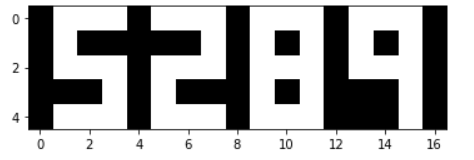

*hint2: you may find the following dict usefull*

In [18]:
numbs = {
      "1": np.array([[0, 1, 1], [1, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 1
      "2": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1]]), # 2
      "3": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 3
      "4": np.array([[1, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 0, 1]]), # 4
      "5": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 5
      "6": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 6
      "7": np.array([[1, 1, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 7
      "8": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 8
      "9": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 9
      "0": np.array([[1, 1, 1], [1, 0, 1], [1, 0, 1], [1, 0, 1], [1, 1, 1]]), # 0
  }

#### advanced

Extend your *show_in_digi* function to be able to display an arbitary float number and negative numbers

# Exercise 3 - Playing with California Housing Dataset

The purpose of this exercise is to learn basic operations of **pandas** library. Use *california_housing_dataset* you can find in google colab to do following operations:

- check what *dataset.describe()* does

- display all rows where *total_bedrooms* column is bigger than 310

- drop also first and last row

- save a mean of values in *households* columns to variable, using *matplotlib* display number of households in the graph (x-axis would be ID, y-axis - numbers of households) as dots with the same color, display also mean as a single line in the graph with different color as dots is

 - check if any of the columns contain NaN values, if yes, replace the NaN values with the arithmetic mean of the whole dataset

 - display *lat* and *long* into plot, *lat* would be on *x* axis and *long* on *y* axis

- choose two arbitrary columns and normalize all values inside using *min-max normalization*:

- Create a Correlation Matrix from all columns

          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1462.000000   
50%     -118.490000     34.250000           29.000000   2127.000000   
75%     -118.000000     37.720000           37.000000   3151.250000   
max     -114.310000     41.950000           52.000000  37937.000000   

       total_bedrooms    population    households  median_income  \
count    17000.000000  17000.000000  17000.000000   17000.000000   
mean       539.410824   1429.573941    501.221941       3.883578   
std        421.499452   1147.852959    384.520841       1.908157   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

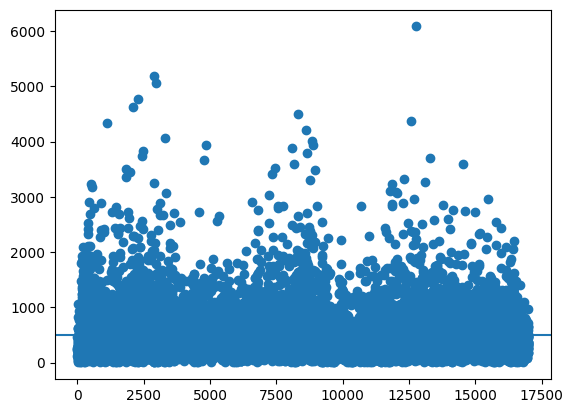

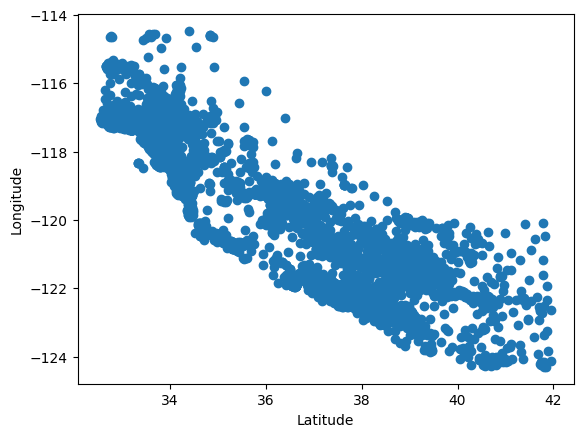

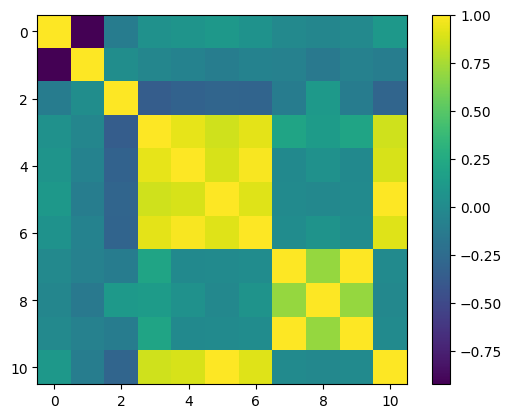

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")
print(df.describe())
filtered = df[df["total_bedrooms"] > 310]
print(filtered)
df = df.iloc[1:-1]
mean_households = df["households"].mean()

plt.scatter(df.index, df["households"])
plt.axhline(mean_households)
plt.show()
df.fillna(df.mean(), inplace=True)
plt.scatter(df["latitude"], df["longitude"])
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()
def min_max_normalize(column):
    return (column - column.min()) / (column.max() - column.min())

df["median_income_norm"] = min_max_normalize(df["median_income"])
df["population_norm"] = min_max_normalize(df["population"])
corr = df.corr()

plt.imshow(corr)
plt.colorbar()
plt.show()